<a href="https://colab.research.google.com/github/Diego-Alanis/INTELIGENCIA-ARTIFICIAL/blob/main/AF7_RNP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AF7: Redes Neuronales Artificiales
# Nombre: Diego Alanis
# Matrícula: 1959092
# Horario de clase: V6

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import mnist

In [ ]:
(train_data, train_labels), (test_data, test_labels) = mnist.load_data()

print("Forma de los datos de entrenamiento:", train_data.shape)
print("Forma de las etiquetas de entrenamiento:", train_labels.shape)
print("Forma de los datos de prueba:", test_data.shape)
print("Forma de las etiquetas de prueba:", test_labels.shape)

Forma de los datos de entrenamiento: (60000, 28, 28)
Forma de las etiquetas de entrenamiento: (60000,)
Forma de los datos de prueba: (10000, 28, 28)
Forma de las etiquetas de prueba: (10000,)


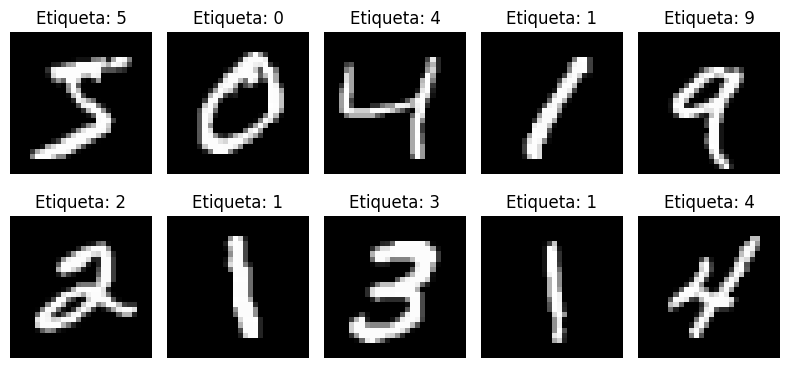

In [ ]:
plt.figure(figsize=(8, 4))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_data[i], cmap="gray")
    plt.title(f"Etiqueta: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [ ]:
# Normalizar los valores de los píxeles de 0-255 a 0-1
train_data = train_data.astype("float32") / 255.0
test_data = test_data.astype("float32") / 255.0

# Convertir imágenes de 28x28 a vectores de 784 valores
train_data = train_data.reshape((train_data.shape[0], 28 * 28))
test_data = test_data.reshape((test_data.shape[0], 28 * 28))

print("Nueva forma de train_data:", train_data.shape)
print("Nueva forma de test_data:", test_data.shape)

Nueva forma de train_data: (60000, 784)
Nueva forma de test_data: (10000, 784)


In [ ]:
model = keras.Sequential([
    layers.Dense(128, activation="relu", input_shape=(784,)),
    layers.Dense(64, activation="relu"),
    layers.Dense(10, activation="softmax")
])

In [ ]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(
    train_data,
    train_labels,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9203 - loss: 0.2732 - val_accuracy: 0.9593 - val_loss: 0.1361
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9666 - loss: 0.1126 - val_accuracy: 0.9657 - val_loss: 0.1134
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9760 - loss: 0.0783 - val_accuracy: 0.9693 - val_loss: 0.1014
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9814 - loss: 0.0589 - val_accuracy: 0.9650 - val_loss: 0.1177
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9846 - loss: 0.0461 - val_accuracy: 0.9728 - val_loss: 0.0981
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9879 - loss: 0.0366 - val_accuracy: 0.9709 - val_loss: 0.1104
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 11s 5ms/step - accuracy: 0.9903 - loss: 0.0306 - val_accuracy: 0.9740 - val_loss: 0.0993
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9919 - loss: 0.0239

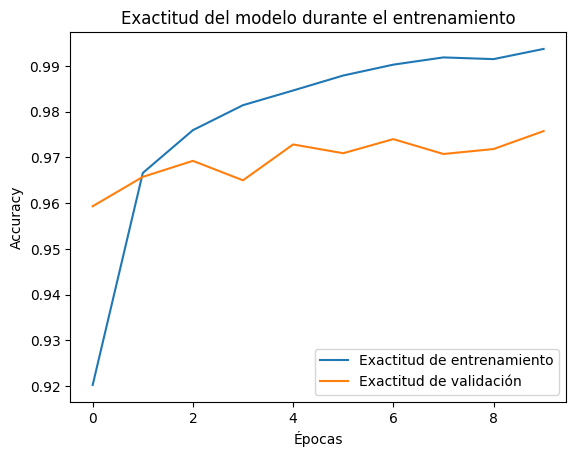

In [ ]:
plt.plot(history.history["accuracy"], label="Exactitud de entrenamiento")
plt.plot(history.history["val_accuracy"], label="Exactitud de validación")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.title("Exactitud del modelo durante el entrenamiento")
plt.legend()
plt.show()

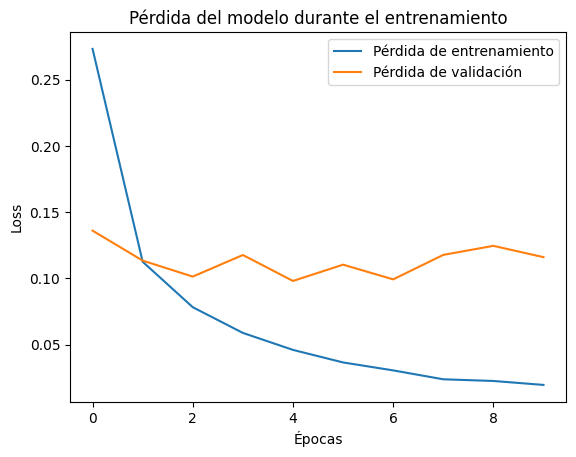

In [ ]:
plt.plot(history.history["loss"], label="Pérdida de entrenamiento")
plt.plot(history.history["val_loss"], label="Pérdida de validación")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.title("Pérdida del modelo durante el entrenamiento")
plt.legend()
plt.show()

In [ ]:
test_loss, test_accuracy = model.evaluate(test_data, test_labels)

print("Pérdida en datos de prueba:", test_loss)
print("Exactitud en datos de prueba:", test_accuracy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9773 - loss: 0.1079
Pérdida en datos de prueba: 0.10787063837051392
Exactitud en datos de prueba: 0.9772999882698059


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


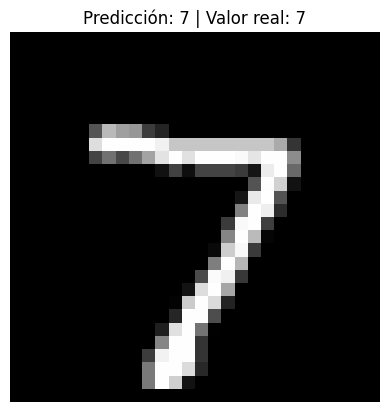

Imagen 1
Predicción del modelo: 7
Valor real: 7
-----------------------------------


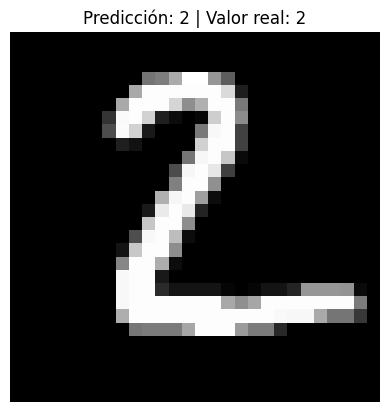

Imagen 2
Predicción del modelo: 2
Valor real: 2
-----------------------------------


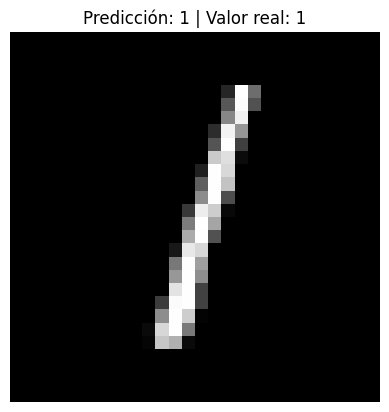

Imagen 3
Predicción del modelo: 1
Valor real: 1
-----------------------------------


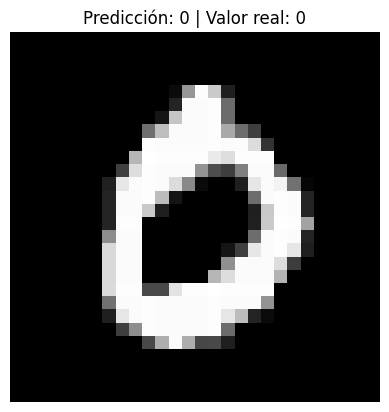

Imagen 4
Predicción del modelo: 0
Valor real: 0
-----------------------------------


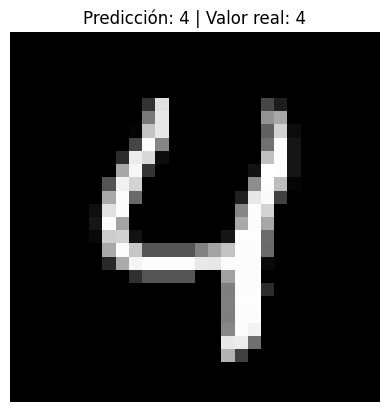

Imagen 5
Predicción del modelo: 4
Valor real: 4
-----------------------------------


In [ ]:
predictions = model.predict(test_data)

for i in range(5):
    predicted_value = np.argmax(predictions[i])
    real_value = test_labels[i]

    plt.imshow(test_data[i].reshape(28, 28), cmap="gray")
    plt.title(f"Predicción: {predicted_value} | Valor real: {real_value}")
    plt.axis("off")
    plt.show()

    print("Imagen", i + 1)
    print("Predicción del modelo:", predicted_value)
    print("Valor real:", real_value)
    print("-----------------------------------")

In [ ]:
print("Conclusión:")
print("Se entrenó una red neuronal artificial prealimentada utilizando el conjunto de datos MNIST.")
print("El modelo utilizó capas densas con activación ReLU y una capa de salida con softmax.")
print("La evaluación con el conjunto de prueba permitió obtener la exactitud del modelo.")
print("Finalmente, se realizaron 5 predicciones comparando el valor predicho con el valor real.")

Conclusión:
Se entrenó una red neuronal artificial prealimentada utilizando el conjunto de datos MNIST.
El modelo utilizó capas densas con activación ReLU y una capa de salida con softmax.
La evaluación con el conjunto de prueba permitió obtener la exactitud del modelo.
Finalmente, se realizaron 5 predicciones comparando el valor predicho con el valor real.
